# Neural Network Starter

Edited from versión 17 from here: https://www.kaggle.com/gogo827jz/jane-street-neural-network-starter

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re, os

import gc
import cudf
import pandas as pd
import numpy as np
import cupy as cp
import janestreet
import math

from sklearn.metrics import roc_auc_score, roc_curve

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from joblib import dump, load
from tqdm.notebook import tqdm

from sklearn.model_selection._split import _BaseKFold, indexable, _num_samples
from sklearn.utils.validation import _deprecate_positional_args

import tensorflow as tf
import tensorflow_addons as tfa

import tensorflow.keras.backend as K
import tensorflow.keras.layers as layers
from tensorflow.keras.callbacks import Callback, ReduceLROnPlateau, ModelCheckpoint, EarlyStopping

# Preprocessing

In [2]:
train = cudf.read_csv('/kaggle/input/jane-street-market-prediction/train.csv')

features = [c for c in train.columns if 'feature' in c]

f_mean = train[features[1:]].mean()
train = train.query('date > 85').reset_index(drop = True) 
train = train.query('weight > 0').reset_index(drop = True)

train[features[1:]] = train[features[1:]].fillna(f_mean)
train['action'] = (train['resp'] > 0).astype('int')

print("Converting")
train = train.to_pandas()
f_mean = f_mean.values.get()
np.save('f_mean.npy', f_mean)


Converting


# Training

In [3]:
def create_mlp(num_columns, num_labels, hidden_units, dropout_rates, label_smoothing,learning_rate):
    
    inp = tf.keras.layers.Input(shape = (num_columns, ))
    x = tf.keras.layers.BatchNormalization()(inp)
    x = tf.keras.layers.Dropout(dropout_rates[0])(x)
    for i in range(len(hidden_units)): 
        x = tf.keras.layers.Dense(hidden_units[i])(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation(tf.keras.activations.swish)(x)
        x = tf.keras.layers.Dropout(dropout_rates[i+1])(x)    
        
    x = tf.keras.layers.Dense(num_labels)(x)
    out = tf.keras.layers.Activation('sigmoid')(x)
    
    model = tf.keras.models.Model(inputs = inp, outputs = out)
    
    model.compile(optimizer = tfa.optimizers.RectifiedAdam(learning_rate = learning_rate),
                  loss = tf.keras.losses.BinaryCrossentropy(label_smoothing=label_smoothing), 
                  metrics = tf.keras.metrics.AUC(name = 'AUC'), 
                 )
    
    return model

In [4]:
# https://github.com/getgaurav2/scikit-learn/blob/d4a3af5cc9da3a76f0266932644b884c99724c57/sklearn/model_selection/_split.py#L2243
class GroupTimeSeriesSplit(_BaseKFold):
    """Time Series cross-validator variant with non-overlapping groups.
    Provides train/test indices to split time series data samples
    that are observed at fixed time intervals according to a
    third-party provided group.
    In each split, test indices must be higher than before, and thus shuffling
    in cross validator is inappropriate.
    This cross-validation object is a variation of :class:`KFold`.
    In the kth split, it returns first k folds as train set and the
    (k+1)th fold as test set.
    The same group will not appear in two different folds (the number of
    distinct groups has to be at least equal to the number of folds).
    Note that unlike standard cross-validation methods, successive
    training sets are supersets of those that come before them.
    Read more in the :ref:`User Guide <cross_validation>`.
    Parameters
    ----------
    n_splits : int, default=5
        Number of splits. Must be at least 2.
    max_train_size : int, default=None
        Maximum size for a single training set.
    Examples
    --------
    >>> import numpy as np
    >>> from sklearn.model_selection import GroupTimeSeriesSplit
    >>> groups = np.array(['a', 'a', 'a', 'a', 'a', 'a',\
                           'b', 'b', 'b', 'b', 'b',\
                           'c', 'c', 'c', 'c',\
                           'd', 'd', 'd'])
    >>> gtss = GroupTimeSeriesSplit(n_splits=3)
    >>> for train_idx, test_idx in gtss.split(groups, groups=groups):
    ...     print("TRAIN:", train_idx, "TEST:", test_idx)
    ...     print("TRAIN GROUP:", groups[train_idx],\
                  "TEST GROUP:", groups[test_idx])
    TRAIN: [0, 1, 2, 3, 4, 5] TEST: [6, 7, 8, 9, 10]
    TRAIN GROUP: ['a' 'a' 'a' 'a' 'a' 'a']\
    TEST GROUP: ['b' 'b' 'b' 'b' 'b']
    TRAIN: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] TEST: [11, 12, 13, 14]
    TRAIN GROUP: ['a' 'a' 'a' 'a' 'a' 'a' 'b' 'b' 'b' 'b' 'b']\
    TEST GROUP: ['c' 'c' 'c' 'c']
    TRAIN: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]\
    TEST: [15, 16, 17]
    TRAIN GROUP: ['a' 'a' 'a' 'a' 'a' 'a' 'b' 'b' 'b' 'b' 'b' 'c' 'c' 'c' 'c']\
    TEST GROUP: ['d' 'd' 'd']
    """
    @_deprecate_positional_args
    def __init__(self,
                 n_splits=2,
                 *,
                 max_train_size=None
                 ):
        super().__init__(n_splits, shuffle=False, random_state=None)
        self.max_train_size = max_train_size

    def split(self, X, y=None, groups=None):
        """Generate indices to split data into training and test set.
        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Training data, where n_samples is the number of samples
            and n_features is the number of features.
        y : array-like of shape (n_samples,)
            Always ignored, exists for compatibility.
        groups : array-like of shape (n_samples,)
            Group labels for the samples used while splitting the dataset into
            train/test set.
        Yields
        ------
        train : ndarray
            The training set indices for that split.
        test : ndarray
            The testing set indices for that split.
        """
        if groups is None:
            raise ValueError(
                "The 'groups' parameter should not be None")
        X, y, groups = indexable(X, y, groups)
        n_samples = _num_samples(X)
        n_splits = self.n_splits
        n_folds = n_splits + 1
        group_dict = {}
        u, ind = np.unique(groups, return_index=True)
        unique_groups = u[np.argsort(ind)]
        n_samples = _num_samples(X)
        n_groups = _num_samples(unique_groups)
        for idx in np.arange(n_samples):
            if (groups[idx] in group_dict):
                group_dict[groups[idx]].append(idx)
            else:
                group_dict[groups[idx]] = [idx]
        if n_folds > n_groups:
            raise ValueError(
                ("Cannot have number of folds={0} greater than"
                 " the number of groups={1}").format(n_folds,
                                                     n_groups))
        group_test_size = n_groups // n_folds
        group_test_starts = range(n_groups - n_splits * group_test_size,
                                  n_groups, group_test_size)
        for group_test_start in group_test_starts:
            train_array = []
            test_array = []
            for train_group_idx in unique_groups[:group_test_start]:
                train_array_tmp = group_dict[train_group_idx]
                train_array = np.sort(np.unique(
                                      np.concatenate((train_array,
                                                      train_array_tmp)),
                                      axis=None), axis=None)
            train_end = train_array.size
            if self.max_train_size and self.max_train_size < train_end:
                train_array = train_array[train_end -
                                          self.max_train_size:train_end]
            for test_group_idx in unique_groups[group_test_start:
                                                group_test_start +
                                                group_test_size]:
                test_array_tmp = group_dict[test_group_idx]
                test_array = np.sort(np.unique(
                                              np.concatenate((test_array,
                                                              test_array_tmp)),
                                     axis=None), axis=None)
            yield [int(i) for i in train_array], [int(i) for i in test_array]

In [5]:
tf.random.set_seed(2020)
batch_size = 4096
hidden_units = [160, 160, 160]
dropout_rates = [0.20, 0.20, 0.20, 0.20]
label_smoothing = 1e-2
learning_rate = 1e-3

oof = np.zeros(len(train['action']))

def utility_gain(pred_val,test_index):

    uniqueValues = train.loc[test_index,'date'].unique()
    min_day = uniqueValues.min().astype('int32')
    max_day = uniqueValues.max().astype('int32')
    nro_days = max_day - min_day +1
    print(min_day)
    print(max_day)
    
    pi = np.zeros(nro_days)
    for j in range(min_day, max_day):        
        index = train.index[train['date'] == j].intersection(test_index)
        m = train.loc[index, 'weight'] * train.loc[index,'resp'] * pred_val[index]
        pi[j-min_day] = np.sum(m) 
        
    t = (np.sum(pi)/ math.sqrt(np.sum(pi**2))) * math.sqrt(250/nro_days)
    utility = min(max(t,0),6) * np.sum(pi)

    return utility

for fold, (tr,te) in enumerate(GroupTimeSeriesSplit().split(train, groups=train['date'])):
    
    X_tr, X_val = train.loc[tr, features].values, train.loc[te, features].values
    y_tr, y_val = train.loc[tr, 'action'].values, train.loc[te, 'action'].values
    
    ckp_path = f'Model_{fold}.hdf5'
    model = create_mlp(X_tr.shape[1], 1, hidden_units, dropout_rates, label_smoothing, learning_rate)
    
    rlr = ReduceLROnPlateau(monitor = 'val_AUC', factor = 0.1, patience = 3, verbose = 0, 
                            min_delta = 1e-4, mode = 'max')
    
    ckp = ModelCheckpoint(ckp_path, monitor = 'val_AUC', verbose = 0, 
                          save_best_only = True, save_weights_only = True, mode = 'max')
    
    es = EarlyStopping(monitor = 'val_AUC', min_delta = 1e-4, patience = 5, mode = 'max', 
                       baseline = None, restore_best_weights = True, verbose = 0)
    
    model.fit(X_tr, y_tr, 
              validation_data = (X_val, y_val), 
              epochs = 200, 
              batch_size = batch_size, 
              callbacks = [rlr, ckp, es], 
              verbose = 0)
                
    oof[te] += model.predict(X_val, batch_size = batch_size * 4).ravel()
    score = roc_auc_score(y_val, oof[te])
    print(f'Fold {fold} ROC AUC:\t', score)
    
    pred_val = model.predict(X_val).ravel()
  
    pred_val = pd.Series(pred_val, index=te)
    pred_val = pred_val.round().astype(int)
    utility = utility_gain(pred_val,te)
    print("%.2f" % utility)
    
    K.clear_session()
    rubbish = gc.collect()


Fold 0 ROC AUC:	 0.5309711524259925
224
361
1299.09
Fold 1 ROC AUC:	 0.5276810436321321
362
499
1544.03


In [6]:
score_oof = roc_auc_score(train['action'].values, oof)
print(score_oof)

0.512420611915317


# Optimise Threshold By Utility Score

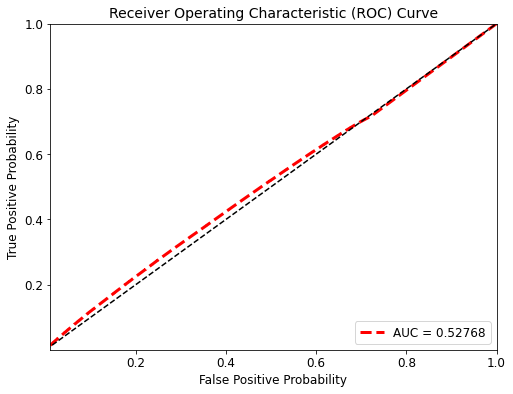

In [7]:
fpr, tpr, th = roc_curve(train['action'].values, oof)
plt.figure(figsize=(8, 6))
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize = 14)
plt.plot(fpr, tpr, 'r--', label = 'AUC = %0.5f' % score, ms = 5, markerfacecolor = 'none', linewidth = '3')
plt.legend(loc = 'lower right', fontsize = 12)
plt.plot([0, 1], [0, 1],'k--')
plt.xlim([0.01, 1])
plt.ylim([0.00001, 1])
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.ylabel('True Positive Probability', fontsize = 12)
plt.xlabel('False Positive Probability', fontsize = 12)
plt.show()

In [8]:
!ls

Model_0.hdf5  Model_1.hdf5  __notebook__.ipynb	f_mean.npy


# Load Models

In [9]:
models = []

for i in range(2):
    clf = create_mlp(len(features), 1, hidden_units, dropout_rates,label_smoothing, learning_rate)
    clf.load_weights(f'./Model_{i}.hdf5')
    #clf.load_weights(f'../input/js-nn-models/JSModel_{i}.hdf5')
    models.append(clf)

In [10]:
f_mean = np.load('./f_mean.npy')
#f_mean = np.load('../input/js-nn-models/f_mean.npy')

# Submitting

In [11]:
env = janestreet.make_env()
env_iter = env.iter_test()


In [12]:
opt_th = 0.501
for (test_df, pred_df) in tqdm(env_iter):
    if test_df['weight'].item() > 0:  
        x_tt = test_df.loc[:, features].values
        if np.isnan(x_tt[:, 1:].sum()):
            x_tt[:, 1:] = np.nan_to_num(x_tt[:, 1:]) + np.isnan(x_tt[:, 1:]) * f_mean    
        
        for i, clf in enumerate(models):
            if i == 0:
                pred = clf(x_tt, training = False).numpy().item() / len(models)
            else:
                pred += clf(x_tt, training = False).numpy().item() / len(models)
                
        pred_df.action = np.where(pred >= opt_th, 1, 0).astype(int)
    else:
        pred_df.action = 0
    env.predict(pred_df)